# Time evolution of $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss

- Units
    - $\hbar=1.0545\times 10^{-34} \,\mathrm{J}\cdot\mathrm{s}$
    - $E_r/\hbar = 8.8593 \,\mathrm{kHz}$
    - $k_r = \sin\left(\frac{\theta}{2}\right)\frac{2\pi}{556 \,\mathrm{nm}} = 6.9462\times10^6 \, \mathrm{m}^{-1}$

Where $\theta=75.854^\circ$
  
- Derived Units
    - $t_r = \hbar/E_r = 0.1129 \,\mathrm{ms}$
    - $m_r = \hbar^2 k_r^2 / 2 E_r = m_{\mathrm{Yb}} = 2.872×10^{-25} \, \mathrm{kg}$

- Hamiltonian
  
$$
\begin{equation}
    H=\sum_{\mathbf{k}}
    \begin{pmatrix}
        c_{\uparrow}^\dagger(\mathbf{k}) & c_{\downarrow}^\dagger(\mathbf{k})
    \end{pmatrix}
    \begin{pmatrix}
        \frac{\hbar^2(q_x-k_r)^2}{2m_{\mathrm{Yb}}} + \frac{\delta}{2} & \frac{\Omega_R}{2} \\
        \frac{\Omega_R}{2} & \frac{\hbar^2(q_x+k_r)^2}{2m_{\mathrm{Yb}}}-\frac{\delta}{2}
    \end{pmatrix}
    \begin{pmatrix}
        c_{\uparrow}(\mathbf{k}) \\
        c_{\downarrow}(\mathbf{k})
    \end{pmatrix}
    -\frac{1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')
\end{equation}
$$

$q_x=[-2.5 k_r, ..., -0.5 k_r, 0, 0.5 k_r, k_r, ..., 3 k_r]$ for $L=12$

- parameters
  - $\hbar/\hbar = 1$
  - $k_r/k_r = 1$
  - $m_{\mathrm{Yb}}/m_r = 1$
  - $\delta/E_r = 4$
  - $\Omega_R/E_r = 3.5$
  - $\gamma/E_r \sim 0.2$


- basis
  
$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$
$$[H]_{\mathcal{B}}$$

In [1]:
import os
import time
import itertools
import functools
import operator
import pickle
from pprint import pprint

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import numpy as np
import tqdm
import matplotlib.pyplot as plt

from ybsoc import *

In [12]:
m_Yb = 1


# q = 1.
# delta = 1.5486
# omega_R = 1.0585

q = 0.    
delta = 0.
omega_R = 0.


gamma = 0.3
# gamma = 0.0


system = YbSOC2bodyLoss(
    d=jnp.pi / 3,
    lengths=[12],
    n_particle=4,
    hbar=1.,
    q=q,
    m_Yb=m_Yb,
    delta=delta,
    omega_R=omega_R,
    gamma=gamma,
    array_type='numpy'
)

hamiltonian = system.dense_hamiltonian(
    display_progress=True
)

  0%|          | 0/10626 [00:00<?, ?it/s]

100%|██████████| 10626/10626 [00:02<00:00, 4932.54it/s]


In [13]:
eigenvalues, eigenvectors = np.linalg.eig(hamiltonian)

In [14]:
pure = system.get_momentum_eigenstate(
    (
        ((0,), 1),
        ((1,), 1),
        ((2,), 1),
        ((11,), 1),
    )
)

mixture = system.get_momentum_eigenstate(
    (
        ((0,), 1),
        ((1,), -1),
        ((2,), 1),
        ((11,), -1),
    )
)

theta = 1.23096 # p(up) = 2/3, p(down) = 1/3
phi = 0
c = (np.cos(theta / 2), np.exp(1j * phi) * np.sin(theta / 2))

superposition = np.zeros_like(mixture)
for c1, c2, c3, c4 in itertools.product([0, 1], repeat=4):
    amp = c[c1] * c[c2] * c[c3] * c[c4]
    basis = system.get_momentum_eigenstate(
        (
            ((0,), 2 * c1 - 1),
            ((1,), 2 * c2 - 1),
            ((2,), 2 * c3 - 1),
            ((11,), 2 * c4 - 1),
        )
    )
    superposition = superposition + amp * basis

In [18]:
# initial_state = pure
initial_state = mixture
# initial_state = superposition

psi_tilde = np.linalg.solve(eigenvectors, initial_state)

t0 = 0
t1 = 0.8 / 0.1129
save_at = np.linspace(t0, t1, 201)
step_size = save_at[1] - save_at[0]

evolution_operator_diag = np.exp(-1j * eigenvalues * step_size / system.hbar)
psis = np.zeros((len(save_at), len(psi_tilde)), dtype=np.complex128)

psis[0, :] = np.einsum('ij,j->i', eigenvectors, psi_tilde)
for i in tqdm.trange(len(save_at)):
    psis[i, :] = np.einsum('ij,j->i', eigenvectors, psi_tilde)
    psi_tilde = evolution_operator_diag * psi_tilde
    
spin_up_numbers, spin_down_numbers = system.momentum_sp_expected_numbers_vectorized(psis)

100%|██████████| 201/201 [00:50<00:00,  3.95it/s]


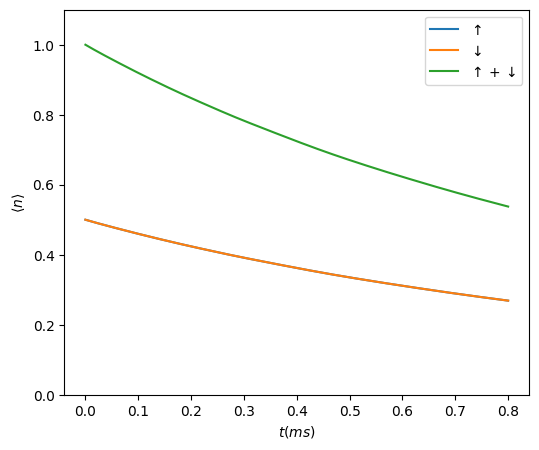

In [19]:
plt.figure(figsize=(6, 5))
t = save_at * 0.1129

# for i in range(8):
#     plt.plot(t, spin_up_numbers[:, i], label=f"$\\uparrow$, {i}")
#     plt.plot(t, spin_down_numbers[:, i], label=f"$\\downarrow$, {i}")

total_up = jnp.sum(spin_up_numbers, axis=1) / system.n_particle
total_down = jnp.sum(spin_down_numbers, axis=1) / system.n_particle

plt.plot(t, total_up, label="$\\uparrow$")
plt.plot(t, total_down, label="$\\downarrow$")
plt.plot(t, total_up + total_down, label="$\\uparrow + \\downarrow$")

plt.ylabel("$\\langle n \\rangle$")
plt.xlabel("$t (ms)$")
plt.ylim(0, 1.1)

plt.legend()
plt.show()

In [7]:
from matplotlib.animation import FFMpegWriter

def make_video(t, up_nums, down_nums, output_path, fps=60):
    """
    a_data, b_data: shape = (num_frames, N)
                    시간축으로 변화하는 a, b 데이터
    output_path: 출력할 mp4 경로
    fps: 초당 프레임 수
    """
    num_frames = len(t)
    N = up_nums.shape[1]
    
    # x축 index
    index = np.arange(N)
    # 막대 너비
    width = ((6 - 1) / N) * 0.75 / 2

    # ---------- (1) 초기 그래프 설정 ----------
    # 첫 프레임(0) 기준으로 막대그래프를 그려두고, 참조를 저장해 놓습니다.
    up_num = up_nums[0]
    down_num = down_nums[0]
    total_num = up_num + down_num

    fig, ax = plt.subplots(figsize=(6, 4))

    # 배경(a+b) 막대: alpha=0.2, color='green', 너비=2*width
    bar_total = ax.bar(index, total_num, width=2*width, alpha=0.2, color='green')

    # a, b 막대: grouped bar
    bar_up = ax.bar(index - width/2, up_num, width, label='up')
    bar_down = ax.bar(index + width/2, down_num, width, label='down')

    ax.set_xticks(index)
    ax.set_xlabel('Index')
    ax.set_ylabel('$\\langle n\\rangle$')
    ax.set_title('t=0.00')
    ax.legend()

    # ---------- (2) 프레임 업데이트 함수 정의 ----------
    def update(frame):
        # 해당 frame에서의 a, b
        up_num = up_nums[frame]
        down_num = down_nums[frame]
        total_num = up_num + down_num
        
        # 배경(a+b) 막대 높이 갱신
        for rect, h in zip(bar_total, total_num):
            rect.set_height(h)
        
        # a 막대 높이 갱신
        for rect, h in zip(bar_up, up_num):
            rect.set_height(h)
        
        # b 막대 높이 갱신
        for rect, h in zip(bar_down, down_num):
            rect.set_height(h)
        
        # 예: 프레임 번호 혹은 시간에 따라 타이틀 갱신
        ax.set_title(f't={t[frame]:.2f} ms')

    # ---------- (3) mp4로 저장 ----------
    writer = FFMpegWriter(fps=fps, metadata=dict(artist='Me'), bitrate=1800)
    with writer.saving(fig, output_path, dpi=100):
        # 전체 프레임 순회하며 그린 뒤 저장
        for frame in tqdm.trange(num_frames, desc="making video"):
            update(frame)
            writer.grab_frame()
    
    plt.close(fig)

In [8]:
from IPython.display import Video

video_path = "../visualizations/output.mp4"

make_video(t, spin_up_numbers, spin_down_numbers, video_path)
Video(video_path, embed=True)

making video: 100%|██████████| 201/201 [00:05<00:00, 36.02it/s]
